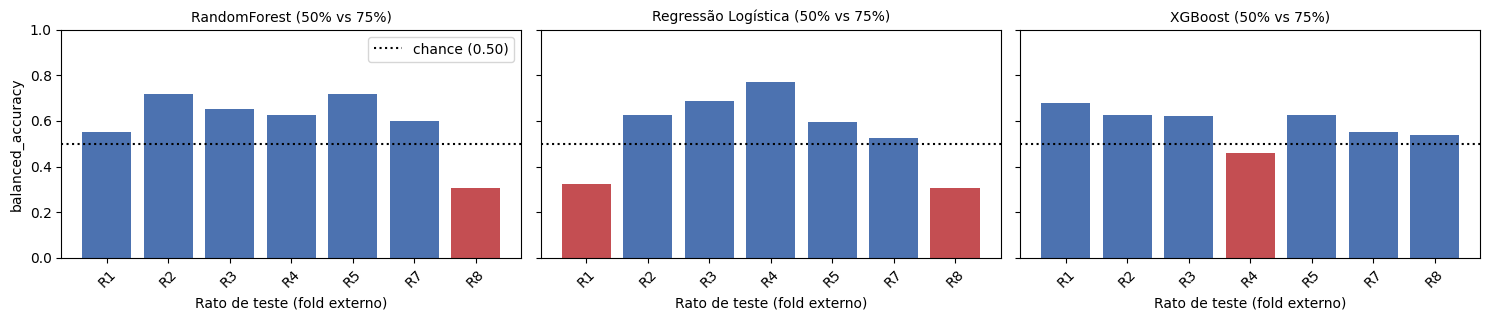

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

arquivos = {
    "RandomForest (50% vs 75%)": "resultados_por_fold_randomforest_50pct_vs_75pct.csv",
    "Regressão Logística (50% vs 75%)": "resultados_por_fold_regressão_logística_50pct_vs_75pct.csv",
    "XGBoost (50% vs 75%)": "resultados_por_fold_xgboost_50pct_vs_75pct.csv",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 3.3), sharey=True)

for ax, (nome_modelo, caminho_csv) in zip(axes, arquivos.items()):
    df = pd.read_csv(caminho_csv).sort_values("fold")
    cores = ["#4C72B0" if v >= 0.5 else "#C44E52" for v in df["balanced_accuracy"]]
    ax.bar(df["rato_teste"].astype(str), df["balanced_accuracy"], color=cores)
    ax.axhline(0.5, color="black", linestyle=":", label="chance (0.50)")
    ax.set_title(nome_modelo, fontsize=10)
    ax.set_xlabel("Rato de teste (fold externo)")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("balanced_accuracy")
axes[0].legend()
plt.tight_layout()
plt.savefig("balanced_accuracy_3_modelos.png", dpi=150)
plt.show()

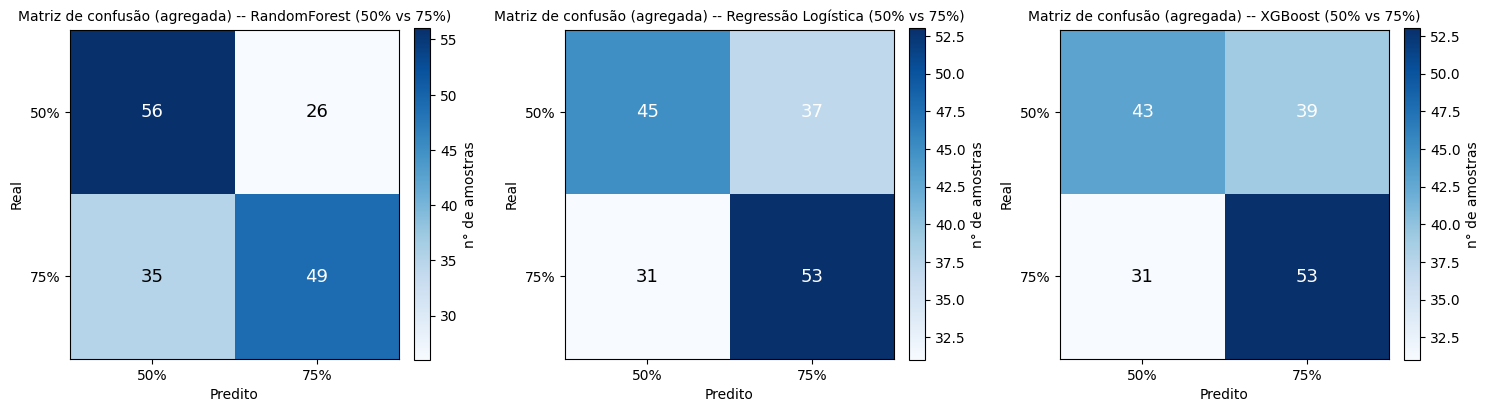

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("10_2_matriz_confusao_por_classe.csv")

modelos = df["modelo"].unique()

fig, axes = plt.subplots(1, len(modelos), figsize=(5 * len(modelos), 4.2))
if len(modelos) == 1:
    axes = [axes]

for ax, modelo in zip(axes, modelos):
    sub = df[df["modelo"] == modelo].set_index("classe_real")

    # monta a matriz 2x2: linha = real, coluna = predito
    # real 50%: acertos -> predito 50%, erros -> predito 75%
    # real 75%: erros -> predito 50%, acertos -> predito 75%
    matriz = np.array([
        [sub.loc["50%", "n_acertos"], sub.loc["50%", "n_erros"]],
        [sub.loc["75%", "n_erros"],   sub.loc["75%", "n_acertos"]],
    ])

    im = ax.imshow(matriz, cmap="Blues")

    for i in range(2):
        for j in range(2):
            valor = matriz[i, j]
            cor_texto = "white" if valor > matriz.max() / 1.6 else "black"
            ax.text(j, i, str(valor), ha="center", va="center",
                    color=cor_texto, fontsize=13)

    ax.set_xticks([0, 1]); ax.set_xticklabels(["50%", "75%"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["50%", "75%"])
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusão (agregada) -- {modelo}", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="n° de amostras")

plt.tight_layout()
plt.savefig("matrizes_confusao_tentativa.png", dpi=150)
plt.show()

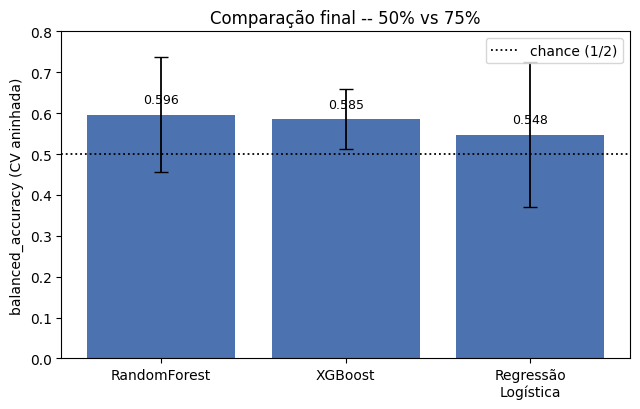

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("comparacao_final_logreg_xgb_50_75.csv")

# nomes curtos só para o eixo x (sem repetir "(50% vs 75%)" em cada barra)
nomes_curtos = {
    "RandomForest (50% vs 75%)": "RandomForest",
    "XGBoost (50% vs 75%)": "XGBoost",
    "Regressão Logística (50% vs 75%)": "Regressão\nLogística",
}
df["modelo_curto"] = df["modelo"].map(nomes_curtos)

# ordena do maior pro menor, só estético
df = df.sort_values("balanced_accuracy_media", ascending=False)

fig, ax = plt.subplots(figsize=(6.5, 4.2))

barras = ax.bar(
    df["modelo_curto"],
    df["balanced_accuracy_media"],
    yerr=df["balanced_accuracy_dp"],
    capsize=5,
    color="#4C72B0",
    error_kw=dict(elinewidth=1.3, ecolor="black"),
)

ax.axhline(0.5, color="black", linestyle=":", linewidth=1.3, label="chance (1/2)")

ax.set_ylabel("balanced_accuracy (CV aninhada)")
ax.set_title("Comparação final -- 50% vs 75%")
ax.set_ylim(0, 0.8)
ax.legend(loc="upper right")

# rótulo com o valor em cima de cada barra
for barra, media in zip(barras, df["balanced_accuracy_media"]):
    ax.text(barra.get_x() + barra.get_width() / 2, media + 0.02,
             f"{media:.3f}", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=0)  # nomes curtos cabem sem rotacionar
plt.tight_layout()
plt.savefig("comparacao_final_modelos.png", dpi=150)
plt.show()

In [1]:
"""
Versão corrigida da Figura 7 (balanced_accuracy por fold externo),
usando barras em vez de linha, já que os ratos no eixo X são categorias
discretas sem ordem/continuidade real entre si.

Espera um dict `resultados` no formato:
    {
        "RandomForest": df_resultados_rf,      # colunas: rato_teste, balanced_accuracy
        "Regressão Logística": df_resultados_logreg,
        "XGBoost": df_resultados_xgb,
    }
onde cada df_resultados vem de resultado["df_resultados"] (já existe no seu
pipeline, dentro de cada saida_rf / saida_logreg / saida_xgb).
"""
import matplotlib.pyplot as plt

def plotar_balanced_accuracy_por_fold_barras(resultados, chance_nivel=0.50,
                                              caminho_saida="figuras/balanced_accuracy_por_fold.png"):
    modelos = list(resultados.keys())
    fig, axes = plt.subplots(1, len(modelos), figsize=(5 * len(modelos), 4), sharey=True)
    if len(modelos) == 1:
        axes = [axes]

    for ax, nome_modelo in zip(axes, modelos):
        df = resultados[nome_modelo]
        cores = ["#4C72B0" if v >= chance_nivel else "#C44E52"
                 for v in df["balanced_accuracy"]]
        ax.bar(df["rato_teste"].astype(str), df["balanced_accuracy"], color=cores)
        ax.axhline(chance_nivel, color="black", linestyle=":", label=f"chance ({chance_nivel:.2f})")
        ax.set_title(f"{nome_modelo} (50% vs 75%)")
        ax.set_xlabel("Rato de teste (fold externo)")
        ax.set_ylim(0, 1)
        ax.legend(loc="upper right", fontsize=8)

    axes[0].set_ylabel("balanced_accuracy")
    plt.tight_layout()
    plt.savefig(caminho_saida, dpi=200, bbox_inches="tight")
    plt.show()
    return fig

print("Função plotar_balanced_accuracy_por_fold_barras pronta para uso.")

Função plotar_balanced_accuracy_por_fold_barras pronta para uso.
